# Power Line and Transmission Tower Segmentation in Aerial Images

### Comparing Class-Imbalance-Aware Loss Functions for Thin-Structure Semantic Segmentation

---

**Course:** MACHINE LEARNING / PROJECT 2
**Group Number:** ML_DS_60_06

**Team Members:**
| Name | Matriculation Number |
|------|----------------------|
| DAVID JOYSON AKKARAPATY | 90159624. |
| OPEYEMI SAMUEL KOLADE | 50029037. |
| SAHEED YAKUBU | 59117739. |

**Date:** 29 JUNE 2026

---


## 1. Problem Statement

- Aerial infrastructure inspection (drones, helicopters) is used to monitor power lines, but manual visual review of footage is slow and labour-intensive.
- Automating this with semantic segmentation could flag cable locations directly from images, reducing manual survey effort.
- **The core technical challenge:** power lines are extremely thin, wire-like structures that occupy a tiny fraction of image pixels, making them very easy for a model to miss entirely.
- **Research question:** *Which loss function — standard BCE, Weighted BCE, Focal Loss, Dice Loss, or Tversky Loss — produces the most accurate segmentation of cables under severe class imbalance?*
- **Project goal:** Train a single fixed model architecture (U-Net + ResNet-34) five times, varying only the loss function, and quantitatively compare results to identify the best-suited loss for this imbalanced segmentation task.

## 2. Dataset

- **Source:** TTPLA (Transmission Towers and Power Lines dataset) — publicly available at [github.com/r3ab/ttpla_dataset](https://github.com/r3ab/ttpla_dataset)
- **Content:** Aerial drone images of power infrastructure with pixel-level polygon annotations
- **Annotation format:** LabelMe-style `.json` files — one per image, containing:
  - `shapes`: list of polygons, each with a `label` (this project's masks use only the `cable` label) and a list of `(x, y)` points
  - `imageHeight` / `imageWidth`: original image dimensions
- **Dataset size:** 1,242 paired images and annotation files
- **Labels / targets:** Binary segmentation mask per image — foreground (cable) vs. background
- **Class balance (measured directly from the data):**
  - Foreground pixels: **2.18%**
  - Background pixels: **97.82%**
  - Background : Foreground ratio ≈ **45 : 1** — confirms this is a severely imbalanced segmentation problem
- **Data split** (fixed random seed = 42 for reproducibility):
  - Train: 869 images (70%)
  - Validation: 186 images (15%)
  - Test: 186 images (15%, held out entirely until final evaluation)
- **Sample data** shown below: original image, binary mask, and overlay for visual verification.

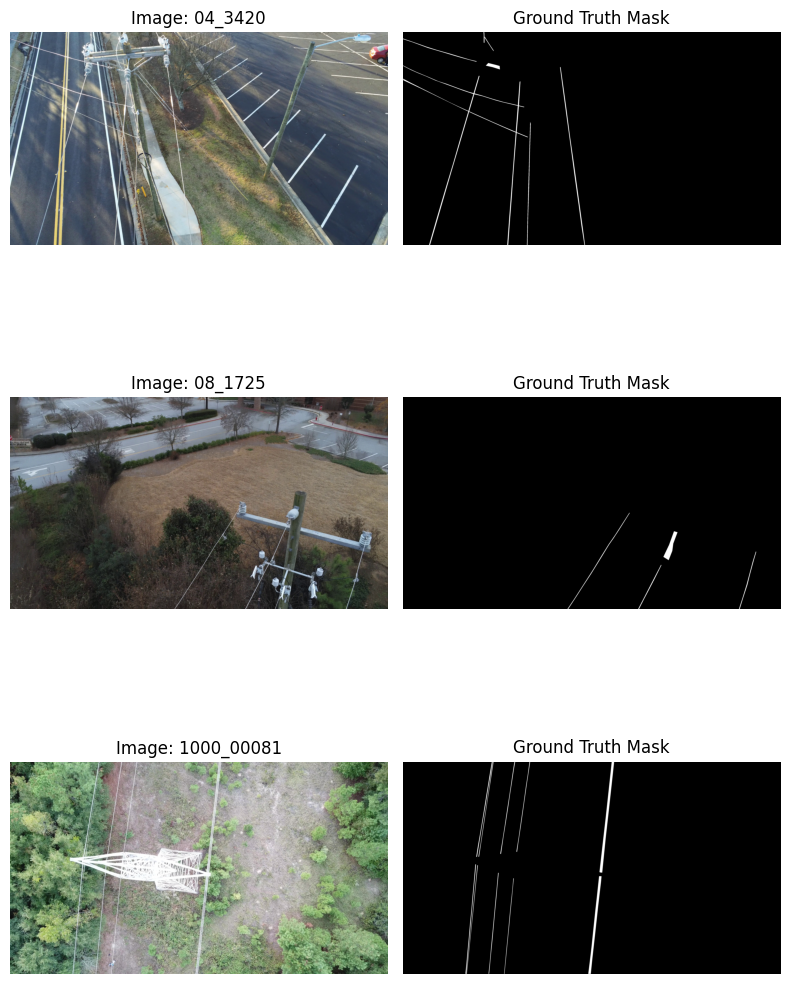

In [1]:
# Display a few sample image/mask pairs from the dataset
# Expects: ./data/images/, ./data/masks/, ./data/splits/test.txt

import os
import numpy as np
from PIL import Image
import matplotlib.pyplot as plt

DATA_DIR   = "./data"
IMAGES_DIR = os.path.join(DATA_DIR, "images")
MASKS_DIR  = os.path.join(DATA_DIR, "masks")
SPLITS_DIR = os.path.join(DATA_DIR, "splits")

with open(os.path.join(SPLITS_DIR, "test.txt")) as f:
    test_names = [line.strip() for line in f if line.strip()]

sample_names = test_names[:3]

fig, axes = plt.subplots(len(sample_names), 2, figsize=(8, 4 * len(sample_names)))
for i, name in enumerate(sample_names):
    img_path = None
    for ext in [".jpg", ".png"]:
        candidate = os.path.join(IMAGES_DIR, name + ext)
        if os.path.exists(candidate):
            img_path = candidate
            break
    mask_path = os.path.join(MASKS_DIR, name + ".png")

    image = Image.open(img_path).convert("RGB")
    mask  = Image.open(mask_path).convert("L")

    axes[i, 0].imshow(image)
    axes[i, 0].set_title(f"Image: {name}")
    axes[i, 0].axis("off")

    axes[i, 1].imshow(mask, cmap="gray")
    axes[i, 1].set_title("Ground Truth Mask")
    axes[i, 1].axis("off")

plt.tight_layout()
plt.show()


In [2]:
# Class imbalance check (pre-computed, displayed here for the record)
# Full computation across all 1,242 masks took several minutes; cached result shown below.

imbalance_stats = {
    "total_images"                  : 1242,
    "foreground_pct"                : "2.18%",
    "background_pct"                : "97.82%",
    "background_to_foreground_ratio": "44.9 : 1",
}

print("Dataset Class Imbalance Summary")
print("-" * 40)
for k, v in imbalance_stats.items():
    print(f"{k:35s}: {v}")


Dataset Class Imbalance Summary
----------------------------------------
total_images                       : 1242
foreground_pct                     : 2.18%
background_pct                     : 97.82%
background_to_foreground_ratio     : 44.9 : 1


## 3. Methodology

**Preprocessing**
- Parsed each LabelMe `.json` annotation file and extracted polygon coordinates for the `cable` label
- Rendered each polygon onto a blank canvas to produce a binary segmentation mask (255 = foreground, 0 = background), matching the original image dimensions
- Verified mask correctness via visual overlay against source images before proceeding

**Split design**
- Random shuffle with a fixed seed (`42`) for full reproducibility
- 70% train / 15% validation / 15% test, split at the image level (no leakage between sets)
- Test set fully held out — never used in training or hyperparameter tuning, only for final evaluation

**Feature extraction / input pipeline**
- Images resized to 512×512 and normalised using ImageNet mean/std (to match the pretrained encoder)
- Masks resized using nearest-neighbour interpolation to preserve binary values
- Training-time augmentation: random horizontal/vertical flip, random rotation (±15°), random brightness/contrast jitter (applied to image only, not mask)

**Modelling**
- Single fixed architecture: U-Net with a ResNet-34 encoder pretrained on ImageNet
- Five independent training runs, identical in every respect except the loss function used
- Optimiser: Adam, learning rate 1e-4, with `ReduceLROnPlateau` scheduling on validation IoU
- 30 training epochs per run, batch size 4

**Validation**
- Validation set evaluated after every epoch (loss + IoU/F1/Precision/Recall)
- Best model checkpoint (highest validation IoU) saved per loss function

**Analysis**
- Final, unbiased comparison performed once on the held-out test set using each saved best model
- Results compared via IoU, F1, Precision, Recall — plus qualitative visual inspection of predictions

## 4. Selected Models

**Architecture (held constant across all experiments): U-Net + ResNet-34 encoder**
- U-Net is the standard architecture for biomedical/aerial image segmentation; its skip connections preserve fine spatial detail — critical for thin structures like cables
- ResNet-34 encoder pretrained on ImageNet provides strong low-level feature extraction (edges, textures) without training from scratch
- Decision: keep the model architecture **fixed** across all experiments so that any performance difference can be attributed only to the loss function (controlled comparison)

**Loss functions compared (the actual independent variable of this study):**
| Loss | Why it was selected |
|------|----------------------|
| **BCE** (baseline) | Standard pixel-wise loss; included as the unweighted baseline to demonstrate the imbalance problem |
| **Weighted BCE** | Simple imbalance correction — applies a fixed positive class weight (44.9, matching the measured background:foreground ratio) |
| **Focal Loss** | Down-weights easy background pixels, forcing the model to focus on hard/rare foreground pixels |
| **Dice Loss** | Directly optimises region overlap (similar to the IoU metric itself), known to perform well on imbalanced segmentation |
| **Tversky Loss** | Generalises Dice with separate penalties for false positives and false negatives (β > α used here to penalise missed cables more) |


## 5. Evaluation Criterion

- **IoU (Intersection over Union)** — primary metric; measures overlap between predicted and ground-truth foreground regions. Standard metric for segmentation tasks and directly reflects how well thin cable pixels are localised.
- **F1 Score (Dice coefficient)** — harmonic mean of precision and recall; robust single-number summary that is not dominated by the overwhelming background class (unlike raw pixel accuracy).
- **Precision** — of all pixels predicted as cable, what fraction are correct. Important because false positives create noisy, unusable segmentation maps.
- **Recall** — of all actual cable pixels, what fraction were detected. Critical for this task specifically: a *missed* cable in a real inspection system is a safety-relevant failure.
- **Why not plain pixel accuracy?** With 97.82% background pixels, a model predicting "all background" would score 97.82% accuracy while detecting zero cables — accuracy is meaningless here. This is precisely why IoU/F1/Precision/Recall were chosen instead.

## 6. Results

**Final test-set results (held-out 186 images, never seen during training), ranked by IoU:**

| Rank | Loss Function | IoU | F1 | Precision | Recall |
|------|---------------|-----|-----|-----------|--------|
| 1 | **Dice** | **0.674** | 0.798 | 0.807 | 0.803 |
| 2 | **Tversky** | 0.659 | 0.786 | 0.738 | 0.857 |
| 3 | **BCE** (baseline) | 0.644 | 0.774 | 0.827 | 0.743 |
| 4 | **Focal** | 0.611 | 0.746 | 0.884 | 0.662 |
| 5 | **Weighted BCE** | 0.431 | 0.585 | 0.435 | 0.971 |

**Comparison with baseline:** Dice Loss improves IoU by **+4.7%** and F1 by **+3.1%** relative to the plain BCE baseline, while keeping precision and recall well balanced (0.807 / 0.803).

**Key observations:**
- Dice Loss achieved the best overall balance of precision and recall, and the highest IoU/F1
- Tversky Loss achieved the highest recall (0.857) among the well-balanced losses — consistent with its design (weighted to penalise missed cables more than false positives)
- Focal Loss was the most conservative — highest precision (0.884) but lowest recall among the top 4, meaning it under-detects cables
- **Weighted BCE underperformed substantially** — a single fixed class weight over-corrected, pushing recall to 0.971 but collapsing precision to 0.435 (the model over-predicts cable almost everywhere)
- This supports the central hypothesis: imbalance-*aware* losses designed for segmentation (Dice, Tversky) outperform naive class-weighting (Weighted BCE) on this task


In [3]:
# Load and display the final test-set comparison table (saved from full evaluation run)
import pandas as pd

test_results = pd.read_csv("./data/results/test_set_comparison.csv")
test_results = test_results.sort_values("test_iou", ascending=False).reset_index(drop=True)
test_results.index += 1
test_results


,loss_function,test_iou,test_f1,test_precision,test_recall
1,dice,0.674220,0.797643,0.807095,0.802641
2,tversky,0.658713,0.785991,0.738331,0.857142
3,bce,0.644080,0.773984,0.827032,0.743446
4,focal,0.611238,0.745914,0.883853,0.662303
5,weighted_bce,0.430627,0.584453,0.435385,0.970929


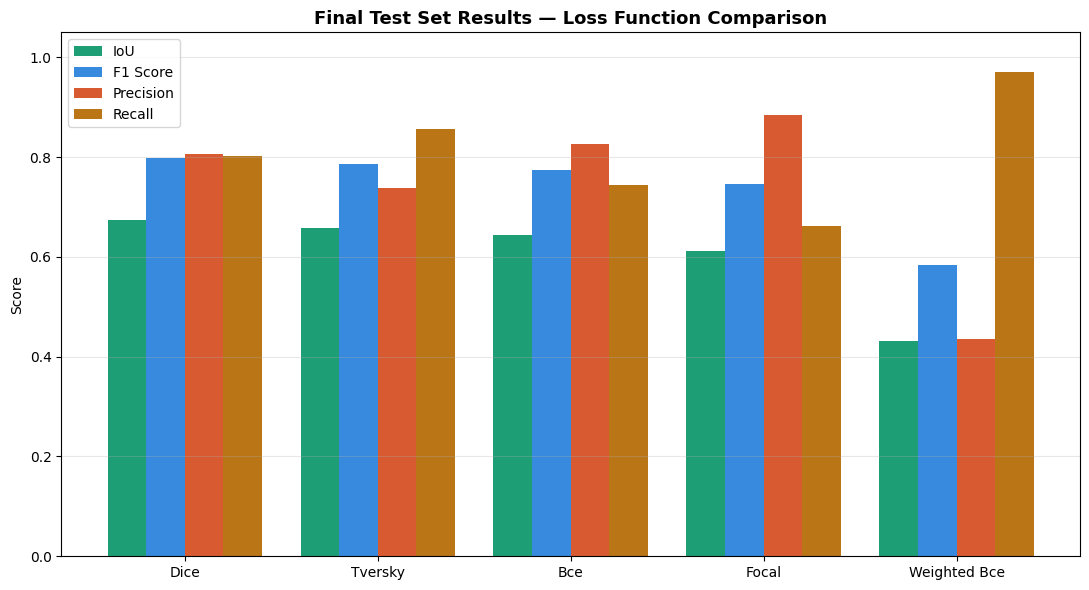

In [4]:
# Final test metrics — grouped bar chart
import matplotlib.pyplot as plt

names = test_results["loss_function"].str.replace("_", " ").str.title()
x = range(len(names))
width = 0.2

fig, ax = plt.subplots(figsize=(11, 6))
ax.bar([i - 1.5*width for i in x], test_results["test_iou"],       width, label="IoU",       color="#1D9E75")
ax.bar([i - 0.5*width for i in x], test_results["test_f1"],        width, label="F1 Score",  color="#378ADD")
ax.bar([i + 0.5*width for i in x], test_results["test_precision"], width, label="Precision", color="#D85A30")
ax.bar([i + 1.5*width for i in x], test_results["test_recall"],    width, label="Recall",    color="#BA7517")

ax.set_xticks(x)
ax.set_xticklabels(names)
ax.set_ylabel("Score")
ax.set_ylim(0, 1.05)
ax.set_title("Final Test Set Results — Loss Function Comparison", fontsize=13, fontweight="bold")
ax.legend()
ax.grid(alpha=0.3, axis="y")
plt.tight_layout()
plt.show()


In [ ]:
# Final test metrics — heatmap by loss function
metric_cols = ["test_iou", "test_f1", "test_precision", "test_recall"]
metric_labels = ["IoU", "F1 Score", "Precision", "Recall"]

heatmap_data = test_results[metric_cols].to_numpy()
row_labels = test_results["loss_function"].str.replace("_", " ").str.title()

fig, ax = plt.subplots(figsize=(7, 5))
im = ax.imshow(heatmap_data, cmap="RdYlGn", vmin=0, vmax=1, aspect="auto")

ax.set_xticks(range(len(metric_labels)))
ax.set_xticklabels(metric_labels)
ax.set_yticks(range(len(row_labels)))
ax.set_yticklabels(row_labels)

for i in range(heatmap_data.shape[0]):
    for j in range(heatmap_data.shape[1]):
        value = heatmap_data[i, j]
        ax.text(j, i, f"{value:.3f}", ha="center", va="center", color="black", fontsize=10, fontweight="bold")

ax.set_title("Final Test Set Metrics — Heatmap by Loss Function", fontsize=13, fontweight="bold")
fig.colorbar(im, ax=ax, label="Score")
plt.tight_layout()
plt.show()


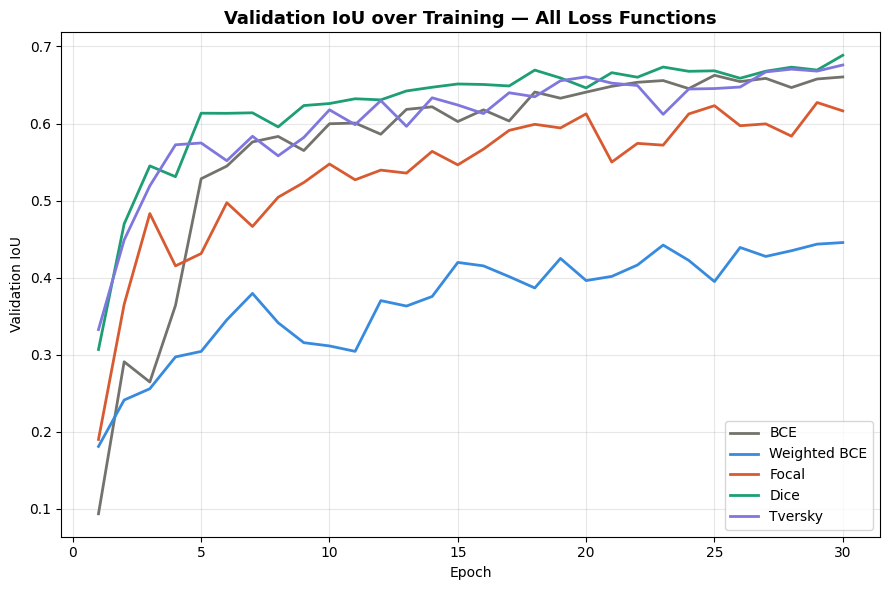

In [5]:
# Training curves — validation IoU per epoch, all 5 loss functions overlaid
import csv

loss_names = ["bce", "weighted_bce", "focal", "dice", "tversky"]
colors = {"bce": "#73726c", "weighted_bce": "#378ADD", "focal": "#D85A30",
          "dice": "#1D9E75", "tversky": "#7F77DD"}
labels = {"bce": "BCE", "weighted_bce": "Weighted BCE", "focal": "Focal",
          "dice": "Dice", "tversky": "Tversky"}

fig, ax = plt.subplots(figsize=(9, 6))
for name in loss_names:
    log_path = f"./data/results/run_{name}/training_log.csv"
    if not os.path.exists(log_path):
        continue
    with open(log_path) as f:
        rows = list(csv.DictReader(f))
    epochs  = [int(r["epoch"]) for r in rows]
    val_iou = [float(r["val_iou"]) for r in rows]
    ax.plot(epochs, val_iou, label=labels[name], color=colors[name], linewidth=2)

ax.set_xlabel("Epoch")
ax.set_ylabel("Validation IoU")
ax.set_title("Validation IoU over Training — All Loss Functions", fontsize=13, fontweight="bold")
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()


## 7. Error Analysis and Limitations

**Observed failure cases:**
- All models struggle most with **very fine, low-contrast cables** against busy backgrounds (e.g. tree canopy, road markings that resemble linear structures)
- **Weighted BCE** frequently over-predicts: it labels road lines, kerbs, and other linear background features as cable, producing noisy false-positive-heavy masks
- **Focal Loss**, despite high precision, misses faint or partially-occluded cable segments — under-detection in cluttered scenes
- Thin cable endpoints near image borders are inconsistently segmented across all models, likely due to limited context from the 512×512 resize

**Limitations of this study:**
- Single architecture tested (U-Net + ResNet-34) — results may not generalise to other backbones (e.g. DeepLabV3+, transformer-based segmenters)
- Training limited to 30 epochs per run due to compute constraints (CPU-only training); all loss curves were still mildly improving at epoch 30, so reported numbers are a lower bound on achievable performance
- Fixed loss hyperparameters (e.g. Tversky α=0.3/β=0.7, Focal γ=2.0) were not tuned via grid search — different settings could shift the ranking
- Single random seed used for the train/val/test split — results have not been validated against multiple splits or cross-validation
- Evaluation is pixel-wise; no connected-component or skeleton-based metrics (which may better reflect real-world usability for thin wire structures) were used

**What could be improved:**
- Hyperparameter search over loss-specific weights (Tversky α/β, Focal γ/α)
- Test additional architectures (DeepLabV3+, transformer-based segmentation heads) under the same controlled comparison
- Incorporate skeleton/clDice-style metrics designed specifically for thin-structure segmentation
- Train for more epochs on GPU hardware to confirm whether the current ranking holds at convergence


## 8. Conclusion

- This project trained a fixed U-Net + ResNet-34 segmentation model five times, varying only the loss function, to identify the best approach for detecting power lines in aerial imagery under severe class imbalance (45:1 background-to-foreground ratio).
- **Answer to the research question:** Dice Loss produced the best overall segmentation performance (IoU 0.674, F1 0.798), narrowly ahead of Tversky Loss (IoU 0.659), and both clearly outperformed the plain BCE baseline (IoU 0.644).
- **Weighted BCE — the simplest imbalance-correction approach — performed worst** (IoU 0.431), demonstrating that naive class weighting is an inferior strategy compared to losses purpose-built for segmentation overlap (Dice, Tversky).
- This validates the project's central hypothesis: **segmentation-specific, imbalance-aware loss functions meaningfully outperform both unweighted and naively-weighted cross-entropy on thin-structure aerial segmentation tasks.**
- For practical infrastructure inspection systems prioritising safety (i.e. not missing real cables), **Tversky Loss** is a strong alternative to Dice given its notably higher recall (0.857 vs 0.803).

## 9. Code Demonstration

This section runs a **live, reproducible demonstration** of the trained pipeline:
1. Load all 5 saved best models (`best_model.pth` per loss function)
2. Run inference on a small sample of held-out test images
3. Display original image, ground truth, and each model's prediction side by side

> **Note on reproducibility:** Full training (30 epochs × 5 loss functions, CPU-only) took several days and is **not** re-run live here. Saved model checkpoints and logs from that full training run are loaded instead. The full training code (`train.py`, `dataset.py`, `model.py`, `losses.py`, `metrics.py`) is included in the project repository and can be re-run end-to-end; the exact commands used are shown below for transparency.

**Commands used to produce the saved results (for reference, not re-executed here):**
```bash
python train.py --loss bce
python train.py --loss weighted_bce
python train.py --loss focal
python train.py --loss dice
python train.py --loss tversky
python evaluate.py
python visualize_results.py
```

**Expected data layout for this notebook (relative paths):**
```
./data/
    images/                  # original .jpg images
    masks/                   # binary .png masks
    splits/train.txt, val.txt, test.txt
    results/
        run_bce/best_model.pth, training_log.csv
        run_weighted_bce/...
        run_focal/...
        run_dice/...
        run_tversky/...
        test_set_comparison.csv
```


In [6]:
# Reproducibility: fix all random seeds
import random
import numpy as np
import torch

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

print(f"Random seed fixed at {SEED} for reproducibility.")


Random seed fixed at 42 for reproducibility.


In [7]:
# Install check — run once before presenting, NOT during the live demo
# All packages below should already be installed.

import importlib

required = ["torch", "torchvision", "segmentation_models_pytorch", "PIL", "matplotlib", "pandas", "numpy"]
for pkg in required:
    spec = importlib.util.find_spec(pkg)
    status = "OK" if spec is not None else "MISSING"
    print(f"{pkg:35s}: {status}")


torch                              : OK
torchvision                        : OK
segmentation_models_pytorch        : OK
PIL                                : OK
matplotlib                         : OK
pandas                             : OK
numpy                              : OK


In [8]:
# Define the model architecture (must match training exactly)
import segmentation_models_pytorch as smp

def get_model(encoder="resnet34", pretrained=False):
    return smp.Unet(
        encoder_name    = encoder,
        encoder_weights = "imagenet" if pretrained else None,
        in_channels     = 3,
        classes         = 1,
        activation      = None,
    )

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")


Using device: cpu


In [9]:
# Load all 5 trained models from saved checkpoints
loss_names = ["bce", "weighted_bce", "focal", "dice", "tversky"]
labels = {"bce": "BCE", "weighted_bce": "Weighted BCE", "focal": "Focal",
          "dice": "Dice", "tversky": "Tversky"}

models = {}
for name in loss_names:
    ckpt_path = f"./data/results/run_{name}/best_model.pth"
    if not os.path.exists(ckpt_path):
        print(f"  [SKIP] {name}: checkpoint not found at {ckpt_path}")
        continue
    m = get_model(pretrained=False).to(device)
    m.load_state_dict(torch.load(ckpt_path, map_location=device))
    m.eval()
    models[name] = m
    print(f"  Loaded: {labels[name]}")

print(f"\n{len(models)} / {len(loss_names)} models loaded successfully.")


  Loaded: BCE
  Loaded: Weighted BCE
  Loaded: Focal
  Loaded: Dice
  Loaded: Tversky

5 / 5 models loaded successfully.


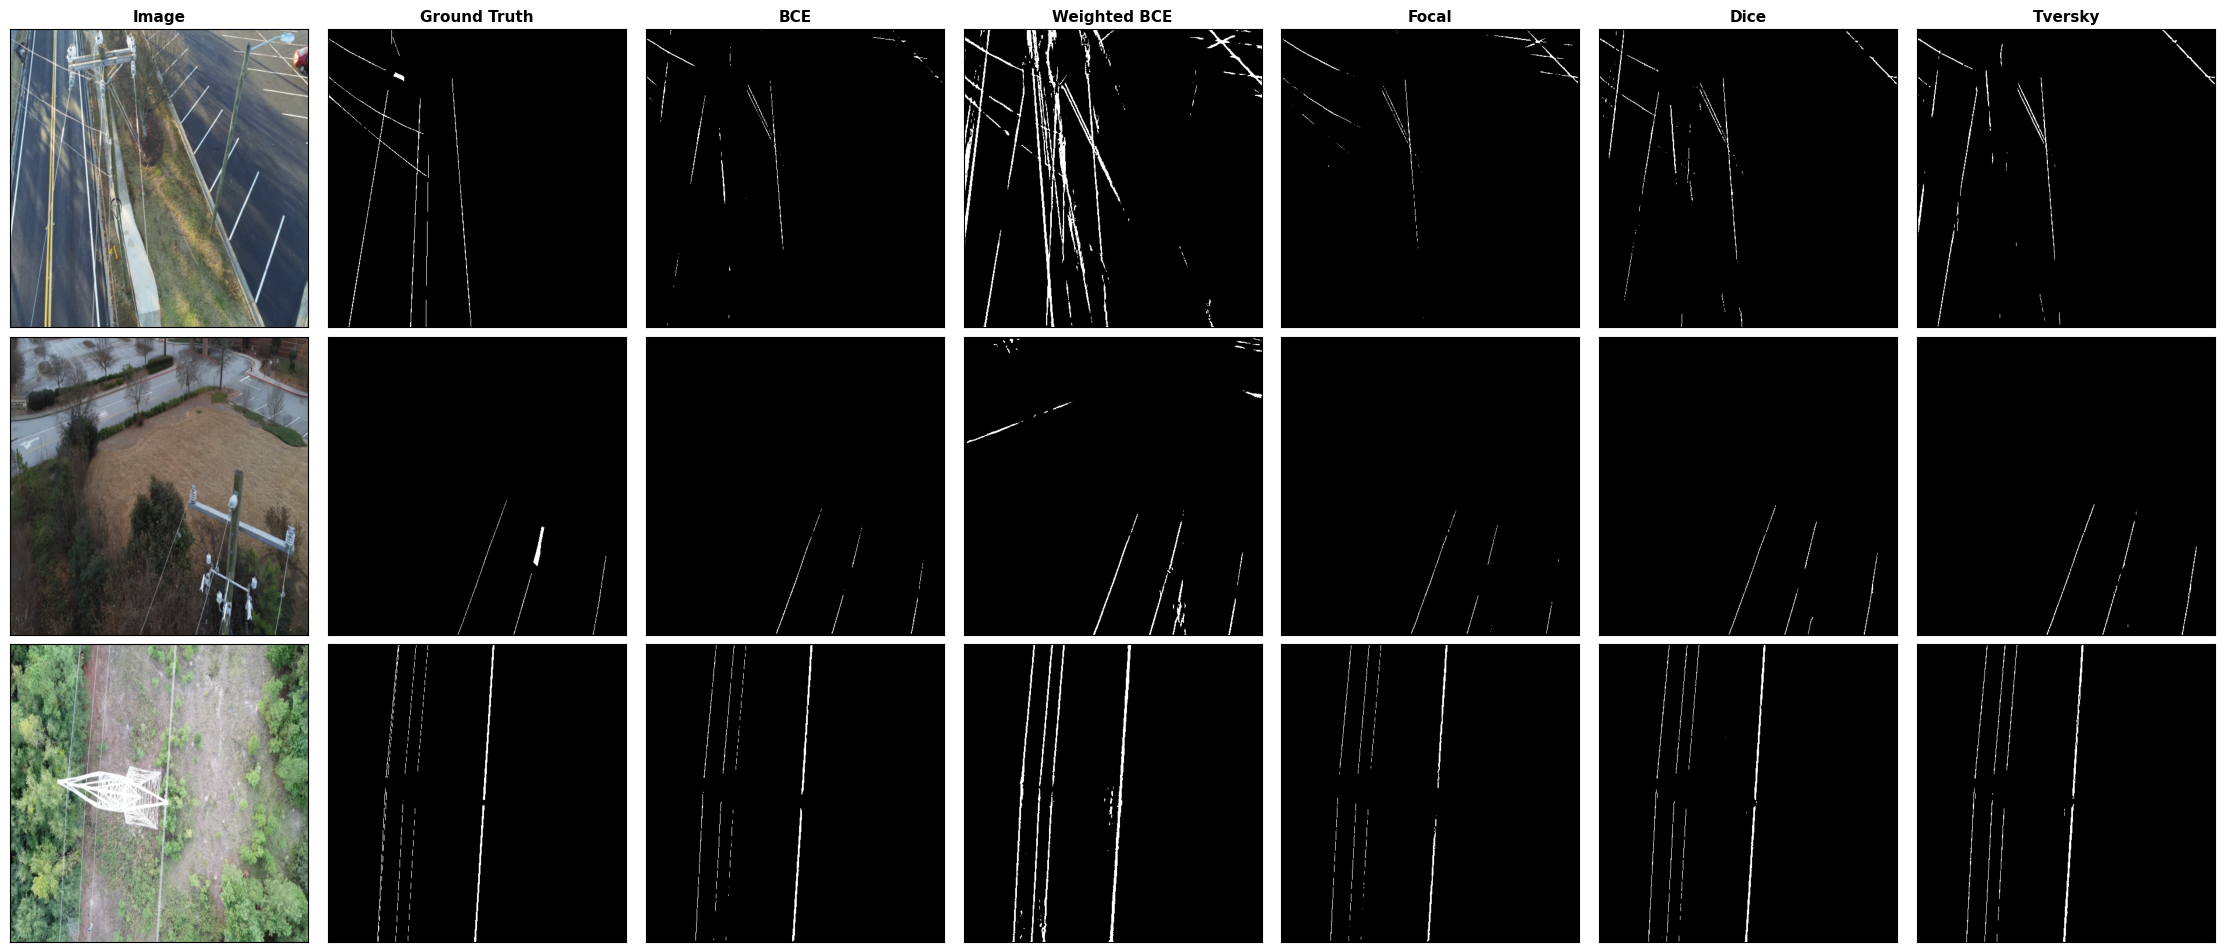

Live demonstration complete: predictions generated for 3 held-out test images.


In [10]:
# Run inference on a small sample of held-out test images and visualise
import torchvision.transforms.functional as TF

IMAGE_SIZE = (512, 512)
NUM_DEMO_SAMPLES = 3

mean = np.array([0.485, 0.456, 0.406])
std  = np.array([0.229, 0.224, 0.225])

def load_and_preprocess(name):
    img_path = None
    for ext in [".jpg", ".png"]:
        candidate = os.path.join(IMAGES_DIR, name + ext)
        if os.path.exists(candidate):
            img_path = candidate
            break
    mask_path = os.path.join(MASKS_DIR, name + ".png")

    image = Image.open(img_path).convert("RGB")
    mask  = Image.open(mask_path).convert("L")

    image = TF.resize(image, IMAGE_SIZE)
    mask  = TF.resize(mask, IMAGE_SIZE, interpolation=TF.InterpolationMode.NEAREST)

    image_t = TF.to_tensor(image)
    image_t = TF.normalize(image_t, mean=mean.tolist(), std=std.tolist())
    mask_np = np.array(mask)

    return image_t, mask_np

demo_names = test_names[:NUM_DEMO_SAMPLES]
n_cols = 2 + len(models)

fig, axes = plt.subplots(len(demo_names), n_cols, figsize=(3.2 * n_cols, 3.2 * len(demo_names)))
if len(demo_names) == 1:
    axes = axes.reshape(1, -1)

col_titles = ["Image", "Ground Truth"] + [labels[n] for n in models.keys()]

with torch.no_grad():
    for row, name in enumerate(demo_names):
        image_t, mask_np = load_and_preprocess(name)

        img_disp = image_t.permute(1, 2, 0).numpy()
        img_disp = (img_disp * std + mean).clip(0, 1)

        axes[row, 0].imshow(img_disp)
        axes[row, 1].imshow(mask_np, cmap="gray")

        input_tensor = image_t.unsqueeze(0).to(device)
        for col, (name_loss, m) in enumerate(models.items(), start=2):
            output = m(input_tensor)
            pred = (torch.sigmoid(output) > 0.5).float().cpu().squeeze().numpy()
            axes[row, col].imshow(pred, cmap="gray")

        for col in range(n_cols):
            axes[row, col].set_xticks([])
            axes[row, col].set_yticks([])
            if row == 0:
                axes[row, col].set_title(col_titles[col], fontsize=11, fontweight="bold")

plt.tight_layout()
plt.show()

print("Live demonstration complete: predictions generated for", len(demo_names), "held-out test images.")


---
### End of Notebook

All code above is self-contained and reproducible given the `./data/` folder structure described in Section 9. Full training scripts (`train.py`, `dataset.py`, `model.py`, `losses.py`, `metrics.py`, `evaluate.py`, `visualize_results.py`) are included in the project repository alongside this notebook.
